# Neural Network for Win Probability Prediction / Classification

In this notebook, we will create a simple fully connected neural network using Pytorch. We will evaluate the quality of the model when trained on the three different datasets used in the logistic regression Notebook.

# 1. Loading Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import copy
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from utils import shuffle_data_df, train_test_split_df, standardise_cols, accuracy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")

df = pd.read_csv("../Data/full_data_enc.csv")
df_odds = pd.read_csv("../Data/odds_data_enc.csv")
df_nodds = pd.read_csv("../Data/nodds_data_enc.csv")

df.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,18,1,0,...,0,0,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,18,1,0,...,0,1,1,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,18,1,1,...,0,1,1,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,18,1,1,...,0,1,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,18,1,1,...,0,1,0,0,1,0,0,0,0,0


In [27]:
# Shuffle data
df_shuff_full = shuffle_data_df(df)
df_shuff_odds = shuffle_data_df(df_odds)
df_shuff_nodds = shuffle_data_df(df_nodds)
df_shuff_full.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,8260,1,1.440,5750,5,2.75,1,35,1,0,...,0,0,0,0,0,0,0,0,0,1
938,12415,1,1.550,6620,3,2.60,1,32,1,1,...,1,0,0,0,0,0,0,0,0,1
1228,4580,5,1.170,1120,47,5.00,1,38,0,0,...,0,1,0,0,0,0,1,0,0,0
683,13845,1,1.002,603,87,34.00,1,28,1,1,...,0,0,1,0,0,0,0,0,0,0
282,7330,4,1.360,2195,15,3.20,1,22,1,0,...,0,1,0,0,0,0,0,0,0,1


In [28]:
# Train test split
df_train_full, df_test_full = train_test_split_df(df_shuff_full, 0.8)
df_train_full, df_val_full = train_test_split_df(df_train_full, 0.8)

df_train_odds, df_test_odds = train_test_split_df(df_shuff_odds, 0.8)
df_train_odds, df_val_odds = train_test_split_df(df_train_odds, 0.8)

df_train_nodds, df_test_nodds = train_test_split_df(df_shuff_nodds, 0.8)
df_train_nodds, df_val_nodds = train_test_split_df(df_train_nodds, 0.8)

In [31]:
# Separating target from predictors
y_train_full, y_val_full, y_test_full = df_train_full["dj_win"].to_numpy().reshape(-1, 1), df_val_full["dj_win"].to_numpy().reshape(-1, 1), df_test_full["dj_win"].to_numpy().reshape(-1, 1)
X_train_full, X_val_full, X_test_full = df_train_full.copy().drop(columns="dj_win").to_numpy(), df_val_full.drop(columns="dj_win").to_numpy(), df_test_full.drop(columns="dj_win").to_numpy()

# Separating target from predictors
y_train_odds, y_val_odds, y_test_odds = df_train_odds["dj_win"].to_numpy().reshape(-1, 1), df_val_odds["dj_win"].to_numpy().reshape(-1, 1), df_test_odds["dj_win"].to_numpy().reshape(-1, 1)
X_train_odds, X_val_odds, X_test_odds = df_train_odds.copy().drop(columns="dj_win").to_numpy(), df_val_odds.drop(columns="dj_win").to_numpy(), df_test_odds.drop(columns="dj_win").to_numpy()

# Separating target from predictors
y_train_nodds, y_val_nodds, y_test_nodds = df_train_nodds["dj_win"].to_numpy().reshape(-1, 1), df_val_nodds["dj_win"].to_numpy().reshape(-1, 1), df_test_nodds["dj_win"].to_numpy().reshape(-1, 1)
X_train_nodds, X_val_nodds, X_test_nodds = df_train_nodds.copy().drop(columns="dj_win").to_numpy(), df_val_nodds.drop(columns="dj_win").to_numpy(), df_test_nodds.drop(columns="dj_win").to_numpy()

In [38]:
df_train_nodds

,dj_pts,dj_rank,opp_pts,opp_rank,dj_win,age,is_outdoor,is_five_sets,5SMA,ATP250,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,8260,1,5750,5,1,35,1,0,0.8,0,...,0,0,0,0,0,0,0,0,0,1
938,12415,1,6620,3,1,32,1,1,1.0,0,...,1,0,0,0,0,0,0,0,0,1
1228,4580,5,1120,47,1,38,0,0,0.8,1,...,0,1,0,0,0,0,1,0,0,0
683,13845,1,603,87,1,28,1,1,1.0,0,...,0,0,1,0,0,0,0,0,0,0
282,7330,4,2195,15,1,22,1,0,0.8,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,577,71,1345,21,1,19,1,0,0.2,0,...,0,0,1,0,0,0,0,0,0,0
139,4470,3,5535,2,0,20,0,0,0.4,0,...,0,1,0,0,0,0,0,1,0,0
435,13630,1,4925,5,1,25,1,1,0.6,0,...,0,1,0,0,0,0,1,0,0,0
11,487,81,1400,21,1,19,0,0,0.4,0,...,0,0,0,1,0,0,0,0,0,0


In [39]:
# Standardise prediction matrix (only columns that are not one-hot-enc)
X_train_std_full = standardise_cols(X_train_full, range(7))
X_val_std_full = standardise_cols(X_val_full, range(7), X_train_full)
X_test_std_full = standardise_cols(X_test_full, range(7), X_train_full)

# Standardise prediction matrix (only columns that are not one-hot-enc)
X_train_std_odds = standardise_cols(X_train_odds, range(2))
X_val_std_odds = standardise_cols(X_val_odds, range(2), X_train_odds)
X_test_std_odds = standardise_cols(X_test_odds, range(2), X_train_odds)

# Standardise prediction matrix (only columns that are not one-hot-enc)
X_train_std_nodds = standardise_cols(X_train_nodds, range(5))
X_val_std_nodds = standardise_cols(X_val_nodds, range(5), X_train_nodds)
X_test_std_nodds = standardise_cols(X_test_nodds, range(5), X_train_nodds)

In [40]:
# Full Dataset
X_train_t_full = torch.tensor(X_train_std_full, dtype=torch.float32)
y_train_t_full = torch.tensor(y_train_full,     dtype=torch.float32)

X_val_t_full = torch.tensor(X_val_std_full, dtype=torch.float32)
y_val_t_full = torch.tensor(y_val_full, dtype=torch.float32)

X_test_t_full = torch.tensor(X_test_std_full, dtype=torch.float32)
y_test_t_full = torch.tensor(y_test_full, dtype=torch.float32)

# Odds Dataset
X_train_t_odds = torch.tensor(X_train_std_odds, dtype=torch.float32)
y_train_t_odds = torch.tensor(y_train_odds,     dtype=torch.float32)

X_val_t_odds = torch.tensor(X_val_std_odds, dtype=torch.float32)
y_val_t_odds = torch.tensor(y_val_odds, dtype=torch.float32)

X_test_t_odds = torch.tensor(X_test_std_odds, dtype=torch.float32)
y_test_t_odds = torch.tensor(y_test_odds, dtype=torch.float32)

# No Odds Dataset
X_train_t_nodds = torch.tensor(X_train_std_nodds, dtype=torch.float32)
y_train_t_nodds = torch.tensor(y_train_nodds,     dtype=torch.float32)

X_val_t_nodds = torch.tensor(X_val_std_nodds, dtype=torch.float32)
y_val_t_nodds = torch.tensor(y_val_nodds, dtype=torch.float32)

X_test_t_nodds = torch.tensor(X_test_std_nodds, dtype=torch.float32)
y_test_t_nodds = torch.tensor(y_test_nodds, dtype=torch.float32)

# 2. Creating Networks

Having loaded the data we need, we will now create our neural network, and specifiy loss and optimiser before we begin to train it and assess it's performance.

In [41]:
g = torch.Generator().manual_seed(SEED)

train_ds_full = TensorDataset(X_train_t_full, y_train_t_full)
train_loader_full = DataLoader(train_ds_full, batch_size=64, shuffle=True, generator=g)

train_ds_odds = TensorDataset(X_train_t_odds, y_train_t_odds)
train_loader_odds = DataLoader(train_ds_odds, batch_size=64, shuffle=True, generator=g)

train_ds_nodds = TensorDataset(X_train_t_nodds, y_train_t_nodds)
train_loader_nodds = DataLoader(train_ds_nodds, batch_size=64, shuffle=True, generator=g)

In [42]:
class NeuralNetwork(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(features, 4 * features),
            nn.ReLU(),
            nn.Linear(4 * features, 1))

    def forward(self, X):
        logits = self.layer(X)
        return torch.sigmoid(logits) # returns probabilities

In [43]:
model_full = NeuralNetwork(30)
model_odds = NeuralNetwork(2)
model_nodds = NeuralNetwork(28)
print(model_full)

NeuralNetwork(
  (layer): Sequential(
    (0): Linear(in_features=30, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=1, bias=True)
  )
)


# 3. Training and Evaluating the Models

In [44]:
def train(dataloader, model, loss, optim, epochs, X_val, y_val):

    train_losses = []
    val_losses = []
    best_val, best_state, patience, no_improve = float("inf"), None, 50, 0

    for epoch in range(epochs):

        if (epoch + 1) % 50 == 0:
            print("Epoch number", epoch + 1)
        batch_losses = []
        model.train()

        for (X, y) in dataloader:

            optim.zero_grad()
            batch_loss = loss(model.forward(X), y)
            batch_losses.append(batch_loss.item())
            batch_loss.backward()
            optim.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss(model.forward(X_val), y_val).item()

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val, best_state, no_improve, best_epoch = val_loss, copy.deepcopy(model.state_dict()), 0, epoch

        else:
            no_improve += 1
            if no_improve > patience:
                break
    
    print("Training Finished")

    model.load_state_dict(best_state)   # roll back to the best epoch

    return train_losses, val_losses, best_epoch

In [45]:
opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-3)
opt_odds = torch.optim.Adam(model_odds.parameters(), lr=1e-3)
opt_nodds = torch.optim.Adam(model_nodds.parameters(), lr=1e-3)

loss = nn.BCELoss()

In [46]:
train_losses_full, val_losses_full, best_epoch_full = train(train_loader_full, model_full, loss, opt_full, 1000, X_val_t_full, y_val_t_full)
train_losses_odds, val_losses_odds, best_epoch_odds = train(train_loader_odds, model_odds, loss, opt_odds, 1000, X_val_t_odds, y_val_t_odds)
train_losses_nodds, val_losses_nodds, best_epoch_nodds = train(train_loader_nodds, model_nodds, loss, opt_nodds, 1000, X_val_t_nodds, y_val_t_nodds)

Epoch number 50
Training Finished
Epoch number 50
Epoch number 100
Training Finished
Epoch number 50
Training Finished


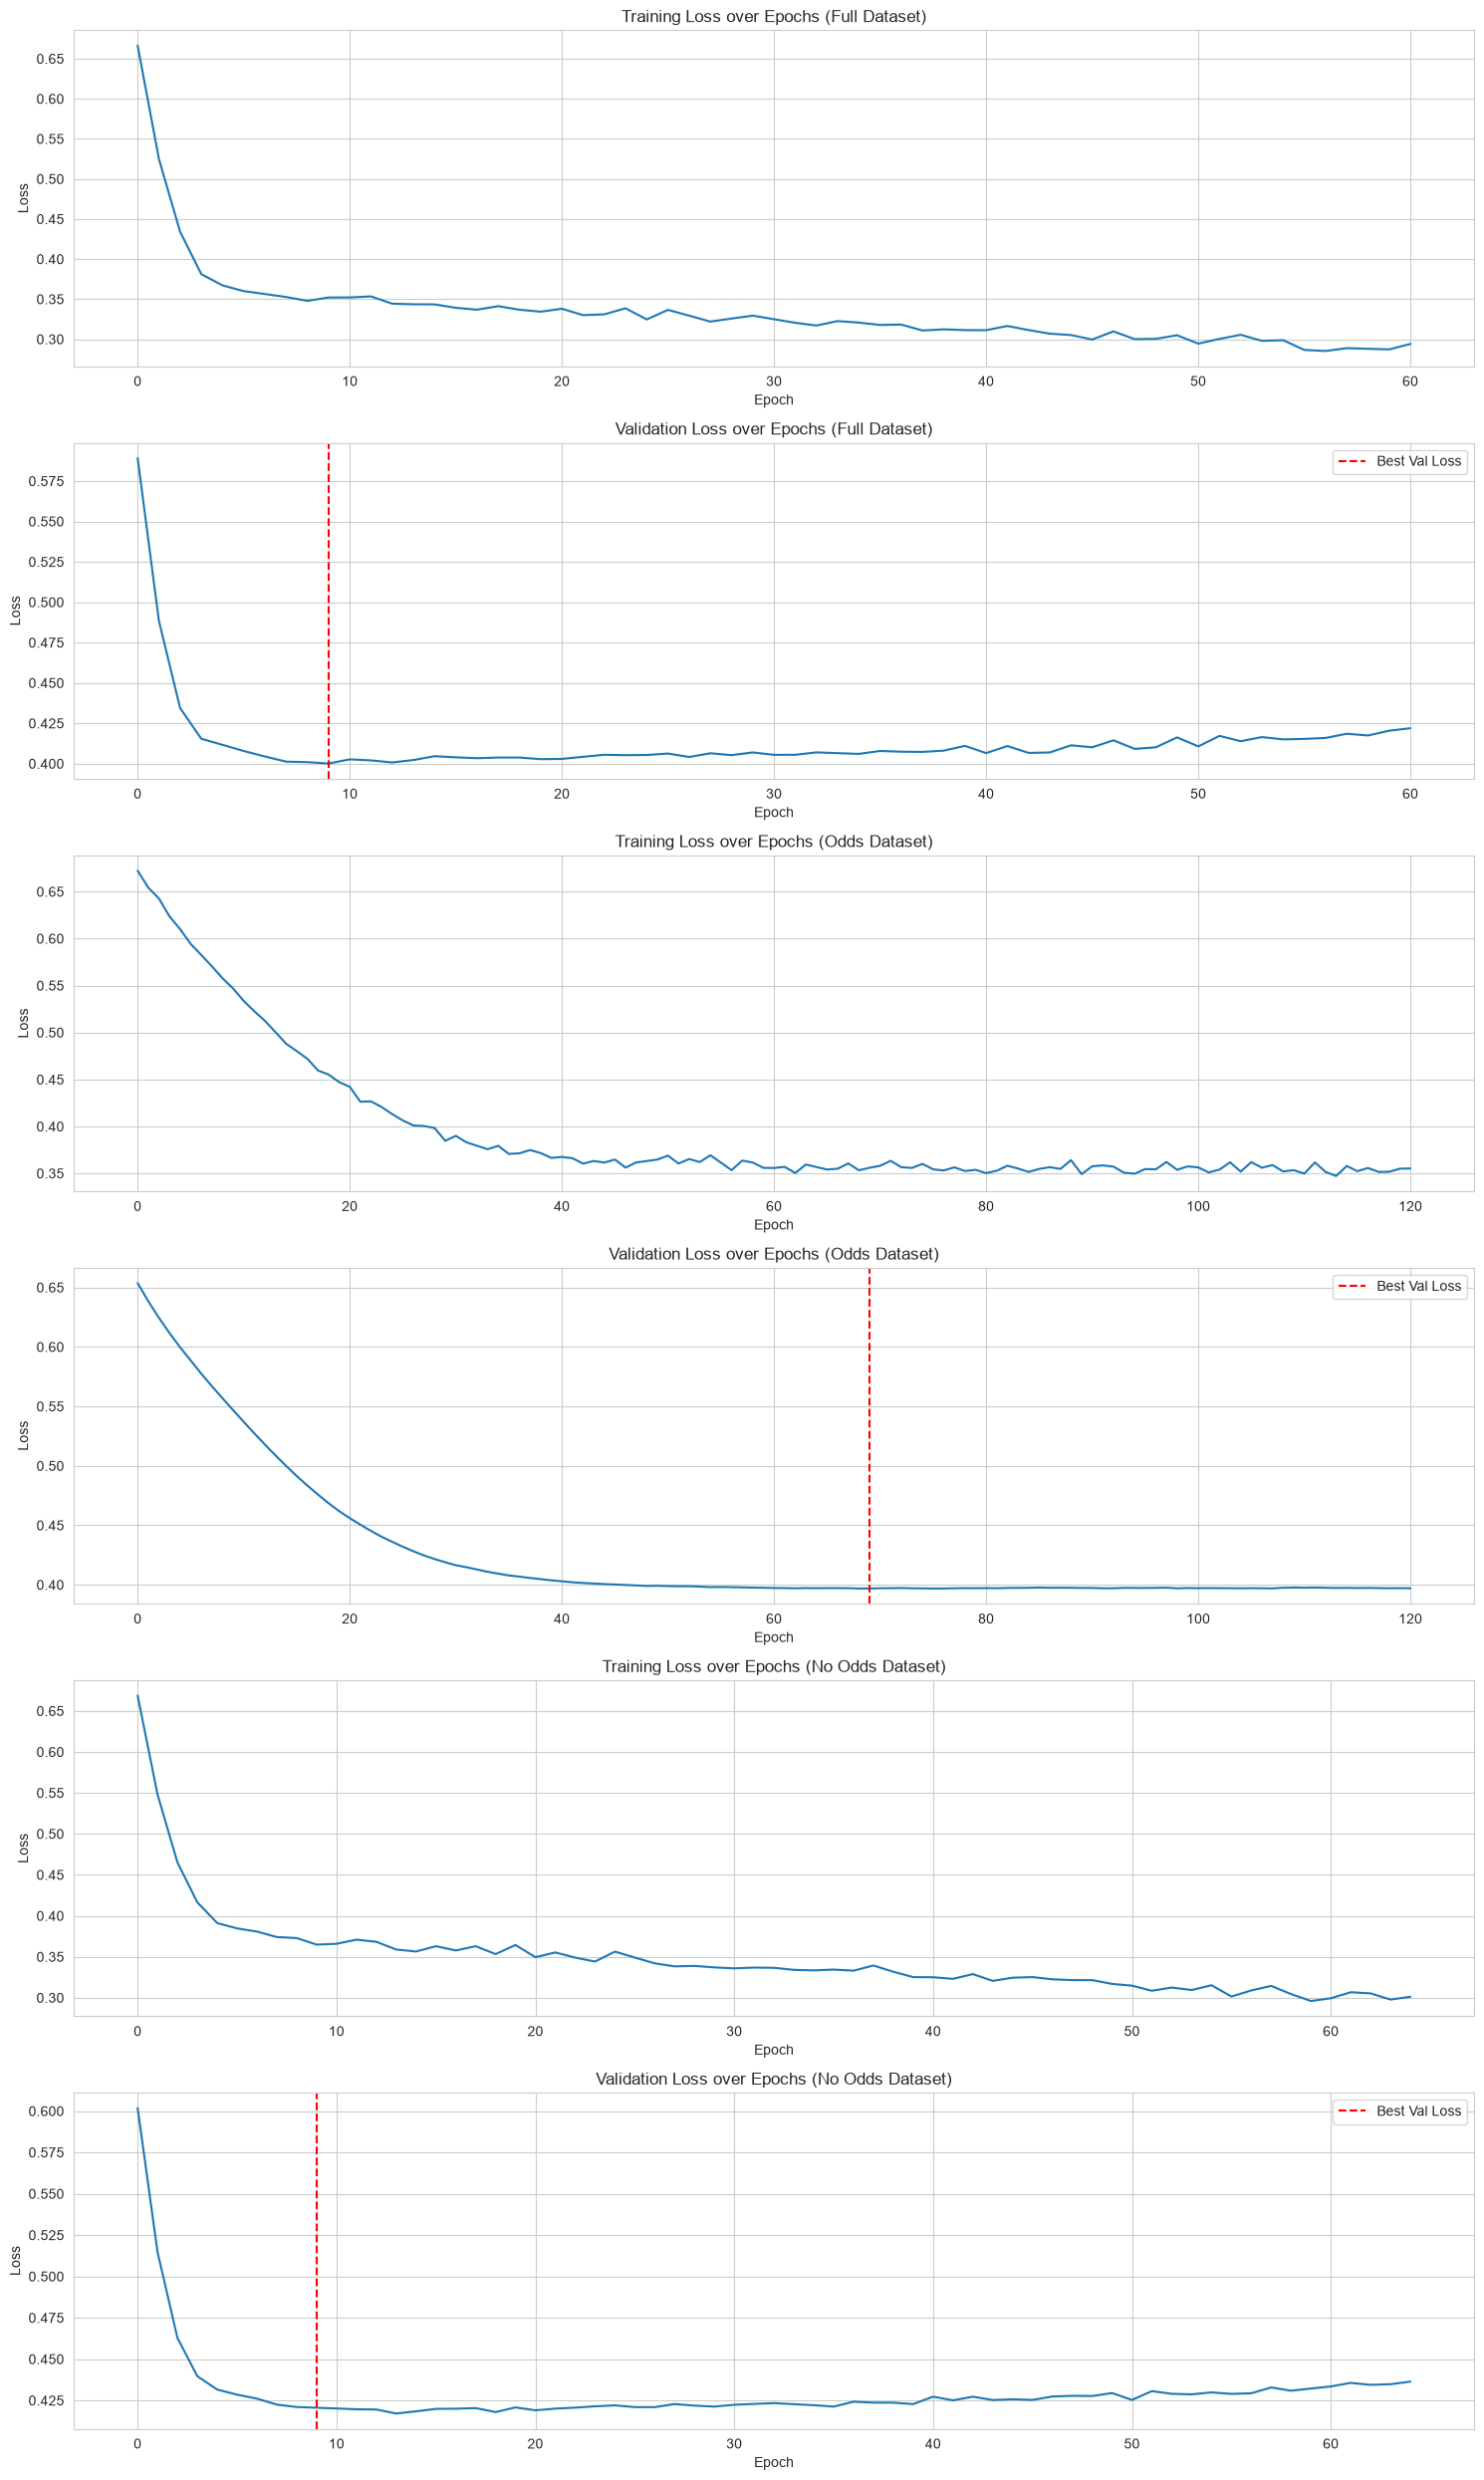

In [53]:
fig, ax = plt.subplots(6, 1, figsize=(15, 25))

ax[0].plot(train_losses_full)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss over Epochs (Full Dataset)")

ax[1].plot(val_losses_full)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Validation Loss over Epochs (Full Dataset)")
ax[1].axvline(best_epoch_full, color="Red", linestyle="--", label="Best Val Loss")
ax[1].legend()

ax[2].plot(train_losses_odds)
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
ax[2].set_title("Training Loss over Epochs (Odds Dataset)")

ax[3].plot(val_losses_odds)
ax[3].set_xlabel("Epoch")
ax[3].set_ylabel("Loss")
ax[3].set_title("Validation Loss over Epochs (Odds Dataset)")
ax[3].axvline(best_epoch_odds, color="Red", linestyle="--", label="Best Val Loss")
ax[3].legend()

ax[4].plot(train_losses_nodds)
ax[4].set_xlabel("Epoch")
ax[4].set_ylabel("Loss")
ax[4].set_title("Training Loss over Epochs (No Odds Dataset)")

ax[5].plot(val_losses_nodds)
ax[5].set_xlabel("Epoch")
ax[5].set_ylabel("Loss")
ax[5].set_title("Validation Loss over Epochs (No Odds Dataset)")
ax[5].axvline(best_epoch_full, color="Red", linestyle="--", label="Best Val Loss")
ax[5].legend()

plt.tight_layout()
plt.show()

# 4. Model Evaluation

In [ ]:
probs = model_full.forward(X_test_t_full)
y_pred = (probs >= 0.5).float()
acc = torch.mean((y_pred == y_test_t_full).float())

In [55]:
print(acc)

tensor(0.8360)


In [ ]:
def confusion_matrix(y_pred, y):

    aa = torch.sum((y_pred == 1) & (y == 1))
    ab = torch.sum((y_pred == 1) & (y == 0))
    ba = torch.sum((y_pred == 0) & (y == 1))
    bb = torch.sum((y_pred == 0) & (y == 0))

    return np.array([[aa, ab], 
                    [ba, bb]])

In [57]:
def performance_analysis(model, X_test, y_test):
    probs = model.forward(X_test)
    y_pred = (probs >= 0.5).float()
    acc = torch.mean((y_pred == y_test).float())

    mat = confusion_matrix(y_pred, y_test)
    positive_precision = mat[0, 0] / (mat[0, 0] + mat[0, 1])
    positive_recall = mat[0, 0] / (mat[0, 0] + mat[1, 0])
    negative_precision = mat[1, 1] / (mat[1, 0] + mat[1, 1])
    negative_recall = mat[1, 1] / (mat[1, 1] + mat[0, 1])

    print("Performance Analysis")
    print("-" * 30)
    print(f"Confusion matrix: {mat}")
    print(f"Positive Precision: {positive_precision :.2f}")
    print(f"Negative Precision: {negative_precision :.2f}")
    print(f"Positive Recall: {positive_recall:.2f}")
    print(f"Negative Recall: {negative_recall:.2f}")

In [60]:
print("FULL DATASET:")
performance_analysis(model_full, X_test_t_full, y_test_full)
print("ODDS DATASET:")
performance_analysis(model_odds, X_test_t_odds, y_test_odds)
print("NO ODDS DATASET:")
performance_analysis(model_nodds, X_test_t_nodds, y_test_nodds)

FULL DATASET:
Performance Analysis
------------------------------
Confusion matrix: [[204  40]
 [  1   5]]
Positive Precision: 0.84
Negative Precision: 0.83
Positive Recall: 1.00
Negative Recall: 0.11
ODDS DATASET:
Performance Analysis
------------------------------
Confusion matrix: [[204  40]
 [  1   5]]
Positive Precision: 0.84
Negative Precision: 0.83
Positive Recall: 1.00
Negative Recall: 0.11
NO ODDS DATASET:
Performance Analysis
------------------------------
Confusion matrix: [[203  42]
 [  2   3]]
Positive Precision: 0.83
Negative Precision: 0.60
Positive Recall: 0.99
Negative Recall: 0.07


C:\Users\morit\AppData\Local\Temp\ipykernel_22504\3902510884.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  aa = torch.sum((y_pred == 1) & (y == 1))
C:\Users\morit\AppData\Local\Temp\ipykernel_22504\3902510884.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ab = torch.sum((y_pred == 1) & (y == 0))
C:\Users\morit\AppData\Local\Temp\ipykernel_22504\3902510884.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ba = torch.sum((y_pred == 0) & (y == 1))
C:\Users\morit\AppData\Local\Temp\ipykernel_22504\3902510884.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bb = torch.sum((y_pred == 0) & (y == 0))


In [20]:
def sweep_threshold(probs, y, thresholds=np.linspace(0.01, 0.99, 99)):
    probs, y = probs.ravel(), y.ravel()
    best_t, best_score, rows = 0.5, -1.0, []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (y == 1)).sum()
        tn = ((preds == 0) & (y == 0)).sum()
        fp = ((preds == 1) & (y == 0)).sum()
        fn = ((preds == 0) & (y == 1)).sum()
        tpr = tp / (tp + fn) if (tp + fn) else 0.0   # win recall
        tnr = tn / (tn + fp) if (tn + fp) else 0.0   # loss recall
        score = 0.5 * (tpr + tnr)                     # balanced accuracy
        rows.append((t, tpr, tnr, score))
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score, rows

In [21]:
best_t, best_score, rows = sweep_threshold(probs.detach().numpy(), y_test_t.detach().numpy())

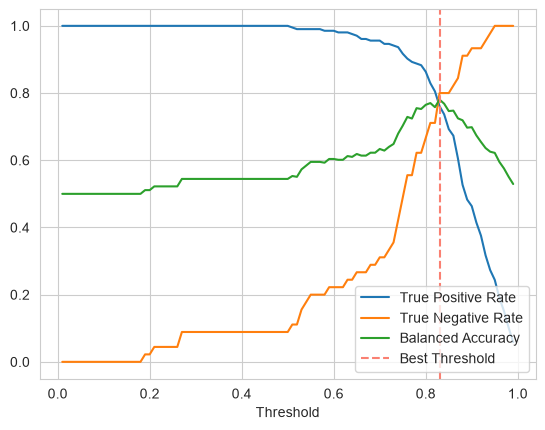

In [22]:
rows = np.array(rows)

plt.plot(np.linspace(0.01, 0.99, 99), rows[:, 1], label="True Positive Rate")
plt.plot(np.linspace(0.01, 0.99, 99), rows[:, 2], label="True Negative Rate")
plt.plot(rows[:, 0], rows[:, 3], label="Balanced Accuracy")
plt.axvline(best_t, color="Salmon", linestyle="--", label="Best Threshold")
plt.legend()
plt.xlabel("Threshold")
plt.show()